<a href="https://colab.research.google.com/github/ZaidAl2004/AER850_Project3/blob/main/AER850_Project3_Eval.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).

image 1/1 /content/drive/MyDrive/project3data/project3data/data/data/evaluation/ardmega.jpg: 832x928 1 Button, 11 Capacitors, 7 Connectors, 1 Diode, 6 ICs, 20 Resistors, 1 Switch, 1 Transistor, 12.8ms
Speed: 6.2ms preprocess, 12.8ms inference, 1.3ms postprocess per image at shape (1, 3, 832, 928)

image 1/1 /content/drive/MyDrive/project3data/project3data/data/data/evaluation/arduno.jpg: 640x928 13 Capacitors, 8 Connectors, 2 Electrolytic Capacitors, 4 ICs, 2 Leds, 1 Pads, 19 Resistors, 10.4ms
Speed: 3.8ms preprocess, 10.4ms inference, 1.3ms postprocess per image at shape (1, 3, 640, 928)

image 1/1 /content/drive/MyDrive/project3data/project3data/data/data/evaluation/rasppi.jpg: 640x928 8 Capacitors, 14 Connectors, 1 Electrolytic Capacitor, 11 ICs, 3 Leds, 1 Pads, 19 Resistors, 1 Switch, 9.8ms
Speed: 5.2ms preprocess, 9.8ms inference, 1.4ms postprocess per 

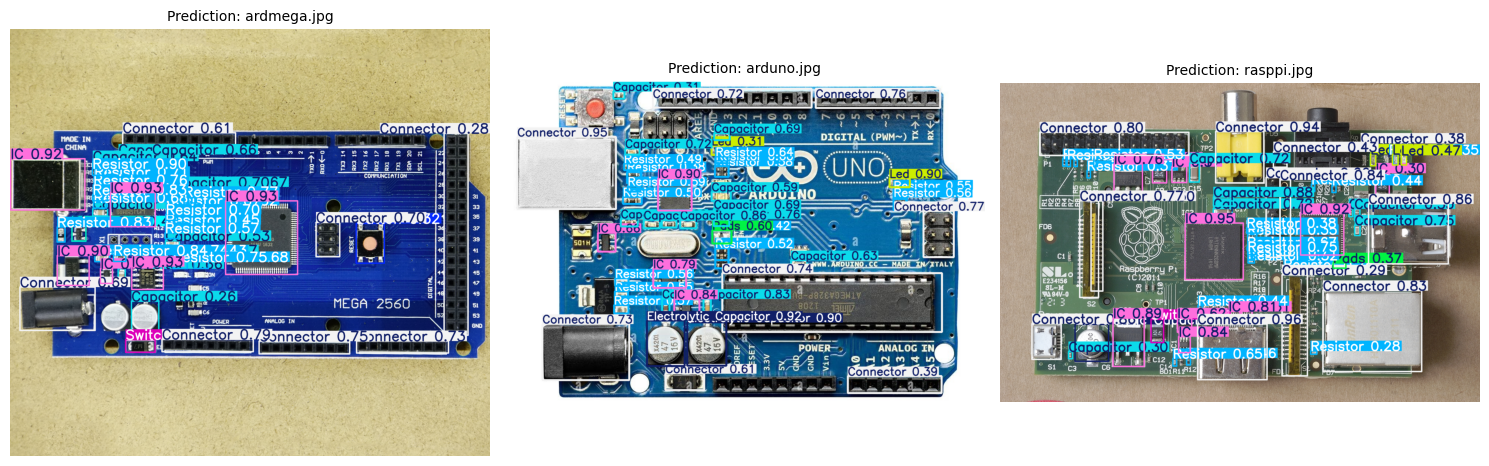

Ultralytics 8.3.233 🚀 Python-3.12.12 torch-2.9.0+cu126 CUDA:0 (Tesla T4, 15095MiB)
val: Fast image access ✅ (ping: 0.4±0.1 ms, read: 176.9±98.4 MB/s, size: 452.6 KB)
val: Scanning /content/drive/MyDrive/project3data/project3data/data/data/valid/labels.cache... 105 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 105/105 65.5Kit/s 0.0s
WARNING ⚠️ Box and segment counts should be equal, but got len(segments) = 26, len(boxes) = 19108. To resolve this only boxes will be used and all segments will be removed. To avoid this please supply either a detect or segment dataset, not a detect-segment mixed dataset.
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 7/7 3.4s/it 23.5s
                   all        105      19108        0.8      0.703      0.757      0.567
                Button         14         45      0.903          1      0.992      0.833
             Capacitor        104       7251      0.765      0.472      0.596      

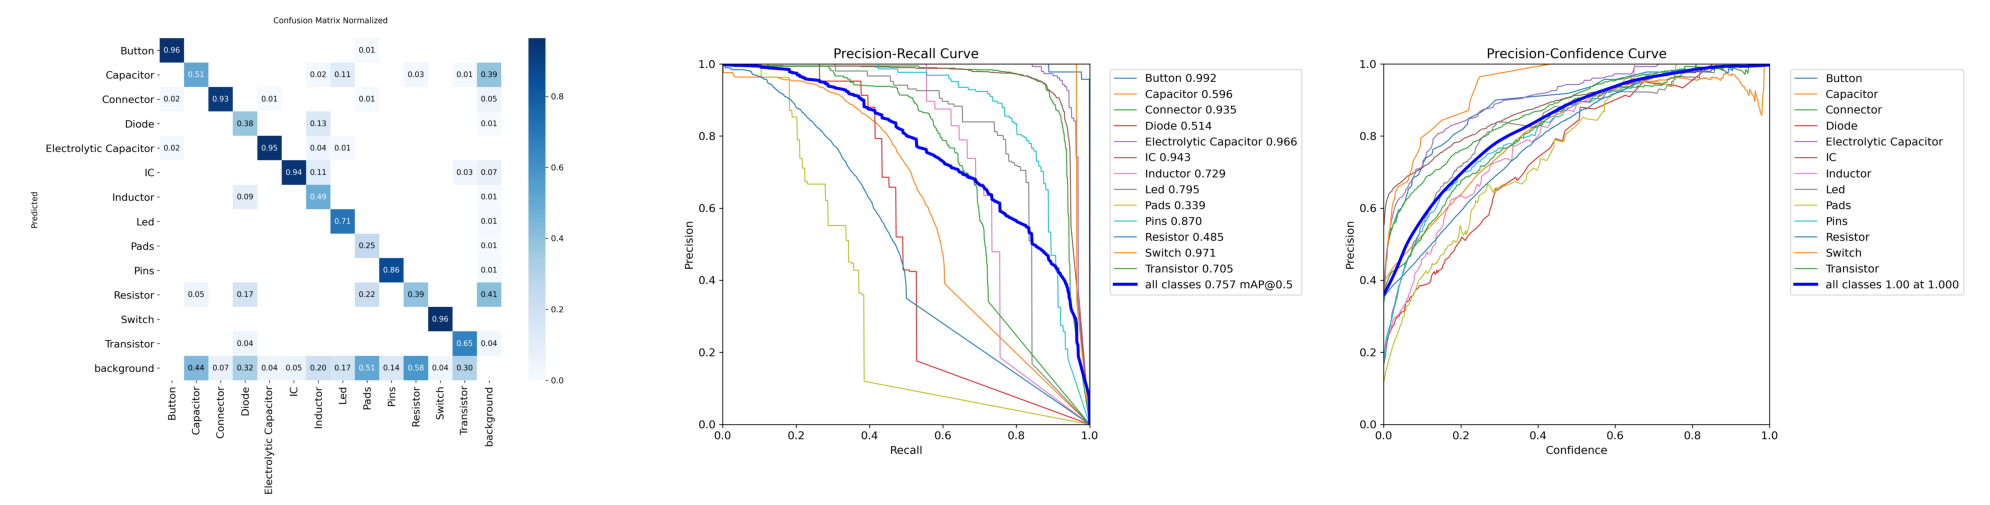

In [12]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import os

#Load image
from google.colab import drive
drive.mount('/content/drive')

#!pip install ultralytics
from ultralytics import YOLO

model = YOLO("/content/drive/MyDrive/best.pt")

#Step 3: Evaluating Model
#Testing for results
import glob

image_folder = "/content/drive/MyDrive/project3data/project3data/data/data/evaluation/*.jpg"   # modify extension if needed
image_paths = sorted(glob.glob(image_folder))

#Predicting and saving each image
pred_images = []

for path in image_paths:
    results = model.predict(path, save=False, imgsz=928)

    #Takes the YOLO image and annotates it, then saves it to pred_images
    annotated = results[0].plot()  # returns a NumPy image
    annotated = cv2.cvtColor(annotated, cv2.COLOR_BGR2RGB)
    pred_images.append((annotated, path))

#Plotting the results from pred_images
num_imgs = len(pred_images)
cols = 3
rows = (num_imgs + cols - 1) // cols  # auto-adjust rows

plt.figure(figsize=(15, 5 * rows))

for i, (img, path) in enumerate(pred_images):
    plt.subplot(rows, cols, i + 1)
    plt.imshow(img)
    plt.title(f"Prediction: {path.split('/')[-1]}", fontsize = 10)
    plt.axis("off")

plt.tight_layout()
plt.show()

project_dir = 'runs/detect'
run_name = 'pcb_detector_v11_val'

metrics = model.val(
    plots=True,
    project=project_dir,
    name=run_name
)  #Runs validation and saves the results for metric analysis

results_path = os.path.join(project_dir, run_name)

files_to_show = [
    "confusion_matrix_normalized.png",
    "BoxPR_curve.png",
    "BoxP_curve.png"
]

# List all files
files = os.listdir(results_path)

    # Sort them alphabetically so they are easier to read
files.sort()

for file_name in files:
    print(f"- {file_name}")


plt.figure(figsize=(20, 6))

for i, file_name in enumerate(files_to_show):
    plt.subplot(1, 3, i + 1)

    full_file_path = os.path.join(results_path, file_name)

    if os.path.exists(full_file_path):
        img = mpimg.imread(full_file_path)
        plt.imshow(img)
        plt.axis('off') # Remove axis ticks
    else:
        plt.text(0.5, 0.5, f"Missing:\n{file_name}",
                 ha='center', va='center', color='red')
        plt.axis('off')

plt.tight_layout()
plt.show()
